In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'ENG WORKSHEET', 'placement_predict_50k.csv', 'colab', 'placement_predict_50k_adjusted.csv']


In [5]:
import pandas as pd

df = pd.read_csv('age_insurance.csv')
df.head()

,Age,Insurance,InsurancePlan
0,56,0,0
1,69,1,2
2,46,1,2
3,32,0,0
4,60,1,2


First 5 rows:
   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2

Dataset shape:
(300, 3)

PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------

Accuracy:
0.7833333333333333

Classification Report:
               precision    recall  f1-score   support

 No Insurance       0.77      0.68      0.72        25
Has Insurance       0.79      0.86      0.82        35

     accuracy                           0.78        60
    macro avg       0.78      0.77      0.77        60
 weighted avg       0.78      0.78      0.78        60


Confusion Matrix:
[[17  8]
 [ 5 30]]

Predictions:
[0 1 1]

Predictions for new ages:
Age 22: Insurance = No (probability of Yes = 0.07)
Age 45: Insurance = Yes (probability of Yes = 0.68)
Age 63: Insurance = Yes (probability of Yes = 0.97)


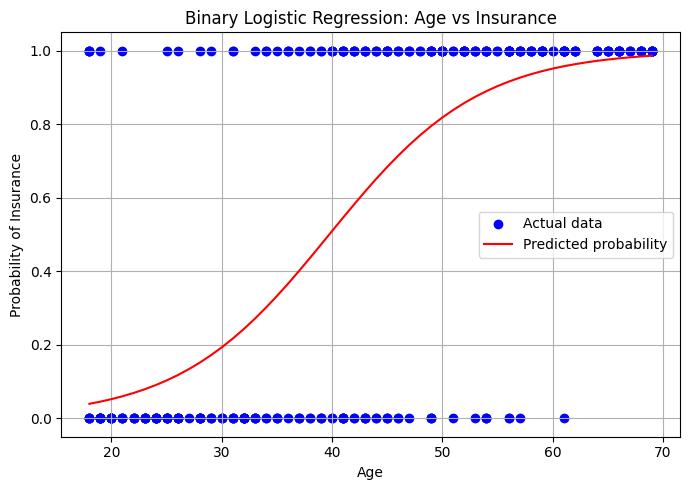


Saved plot -> binary_logistic_plot.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ---------------------------------------------------------
# STEP 1: Load the data
# ---------------------------------------------------------

df = pd.read_csv("age_insurance.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)


# =========================================================
# PART 1: BINARY LOGISTIC REGRESSION
# Feature: Age -> Target: Insurance
# 0 = No Insurance
# 1 = Has Insurance
# =========================================================

print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)


# Feature
X = df[["Age"]]

# Target
y = df["Insurance"]


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Create Logistic Regression model
binary_model = LogisticRegression()


# Train the model
binary_model.fit(X_train, y_train)


# Make predictions
y_pred = binary_model.predict(X_test)


# ---------------------------------------------------------
# MODEL EVALUATION
# ---------------------------------------------------------

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Insurance", "Has Insurance"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# =========================================================
# PREDICT FOR NEW PEOPLE
# =========================================================

new_age = pd.DataFrame({
    "Age": [22, 45, 63]
})


# Predict class
predictions = binary_model.predict(new_age)

print("\nPredictions:")
print(predictions)


# Predict probability of having insurance
probabilities = binary_model.predict_proba(new_age)[:, 1]


# Display results
print("\nPredictions for new ages:")

for age_val, pred, prob in zip(
    new_age["Age"],
    predictions,
    probabilities
):
    insurance_status = "Yes" if pred == 1 else "No"

    print(
        f"Age {age_val}: "
        f"Insurance = {insurance_status} "
        f"(probability of Yes = {prob:.2f})"
    )


# =========================================================
# PLOT: AGE VS INSURANCE WITH S-CURVE
# =========================================================

plt.figure(figsize=(7, 5))


# Actual data
plt.scatter(
    df["Age"],
    df["Insurance"],
    color="blue",
    label="Actual data"
)


# Age range for prediction
age_range = pd.DataFrame({
    "Age": range(
        int(df["Age"].min()),
        int(df["Age"].max()) + 1
    )
})


# Predicted probability
predicted_probability = binary_model.predict_proba(
    age_range
)[:, 1]


# Logistic regression S-curve
plt.plot(
    age_range["Age"],
    predicted_probability,
    color="red",
    label="Predicted probability"
)


plt.xlabel("Age")
plt.ylabel("Probability of Insurance")
plt.title("Binary Logistic Regression: Age vs Insurance")

plt.legend()
plt.grid(True)

plt.tight_layout()


# Save plot
plt.savefig("binary_logistic_plot.png")

plt.show()

print("\nSaved plot -> binary_logistic_plot.png")

In [8]:
import pandas as pd

df = pd.read_csv('age_insurance.csv')
df.head()

,Age,Insurance,InsurancePlan
0,56,0,0
1,69,1,2
2,46,1,2
3,32,0,0
4,60,1,2


In [9]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (300, 3)

Columns:
Index(['Age', 'Insurance', 'InsurancePlan'], dtype='object')

Missing values:
Age              0
Insurance        0
InsurancePlan    0
dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Feature
X = df[["Age"]]

# Target
y = df["Insurance"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Insurance", "Has Insurance"]
))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7833333333333333

Classification Report:
               precision    recall  f1-score   support

 No Insurance       0.77      0.68      0.72        25
Has Insurance       0.79      0.86      0.82        35

     accuracy                           0.78        60
    macro avg       0.78      0.77      0.77        60
 weighted avg       0.78      0.78      0.78        60


Confusion Matrix:
[[17  8]
 [ 5 30]]


In [11]:
new_age = pd.DataFrame({
    "Age": [22, 45, 63]
})

predictions = model.predict(new_age)
probabilities = model.predict_proba(new_age)[:, 1]

for age, prediction, probability in zip(
    new_age["Age"],
    predictions,
    probabilities
):
    status = "Has Insurance" if prediction == 1 else "No Insurance"

    print(
        f"Age {age}: {status} "
        f"(Probability = {probability:.2f})"
    )

Age 22: No Insurance (Probability = 0.07)
Age 45: Has Insurance (Probability = 0.68)
Age 63: Has Insurance (Probability = 0.97)


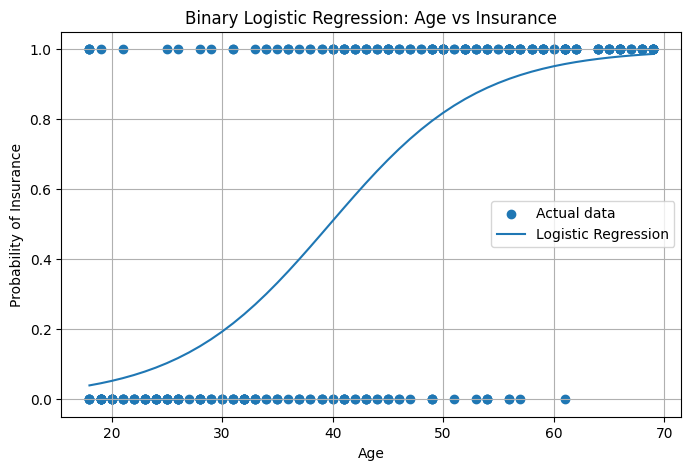

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Actual data
plt.scatter(
    df["Age"],
    df["Insurance"],
    label="Actual data"
)

# Age range
age_range = pd.DataFrame({
    "Age": range(
        int(df["Age"].min()),
        int(df["Age"].max()) + 1
    )
})

# Probability predictions
probability = model.predict_proba(age_range)[:, 1]

# S-curve
plt.plot(
    age_range["Age"],
    probability,
    label="Logistic Regression"
)

plt.xlabel("Age")
plt.ylabel("Probability of Insurance")
plt.title("Binary Logistic Regression: Age vs Insurance")
plt.legend()
plt.grid(True)
plt.show()